In [1]:
import numpy as np
X=2*np.random.rand(100,1)
noise=np.random.randn(100,1)
y=4+3*X+noise
import pandas as pd
df=pd.DataFrame(data=np.hstack((X,y)),columns=['X','y'])
df.head()

,X,y
0,1.447973,9.354990
1,0.509188,5.938357
2,0.501618,4.553805
3,0.389826,4.469193
4,1.291658,8.791680


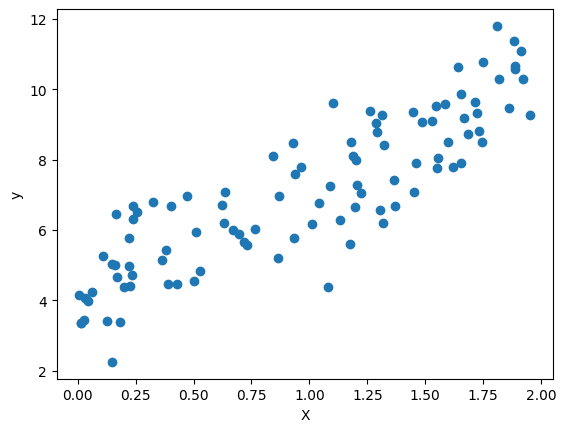

In [ ]:
# Visualizing the data
import matplotlib.pyplot as plt
plt.scatter(X,y)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [3]:
#first defining the gradient descent function
def gradient_descent(m_now, b_now, points, L):
    m_gradient = 0
    b_gradient = 0
    N = float(len(points))
    for i in range(0, len(points)):
        x = points[i, 0]
        y = points[i, 1]
        m_gradient += -(2/N) * x * (y - ((m_now * x) + b_now))
        b_gradient += -(2/N) * (y - ((m_now * x) + b_now))
    m_now -= L * m_gradient
    b_now -= L * b_gradient
    return m_now, b_now

m:  3.4191638206247963
b:  3.5349580583740017


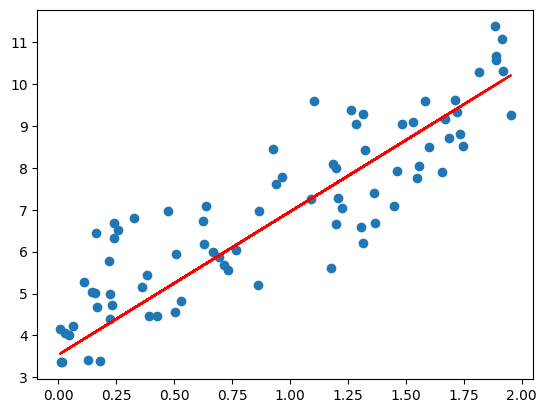

In [8]:
#splitting the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# initializing the parameters
m = 0
b = 0
L = 0.001 # The learning Rate
epochs = 1000 # The number of iterations to perform gradient descent
for i in range(epochs):
    m, b = gradient_descent(m, b, np.hstack((X_train, y_train)), L)
print("m: ", m)
print("b: ", b)
plt.scatter(X_train, y_train)
plt.plot(X_train, m*X_train + b, color='red')
plt.show()

In [9]:
# evaluating the model on the training and testing sets
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_train_pred = m*X_train + b
y_test_pred = m*X_test + b

# Calculate metrics for the training set
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)

# Calculate metrics for the testing set
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Training Set Metrics:")
print("MSE: ", train_mse)
print("R^2: ", train_r2)
print("MAE: ", train_mae)
print("Root Mean Squared Error (RMSE): ", np.sqrt(train_mse))

print("\nTesting Set Metrics:")
print("MSE: ", test_mse)
print("R^2: ", test_r2)
print("MAE: ", test_mae)
print("Root Mean Squared Error (RMSE): ", np.sqrt(test_mse))

Training Set Metrics:
MSE:  1.0818358901444598
R^2:  0.7379494590750839
MAE:  0.8498029551461984
Root Mean Squared Error (RMSE):  1.0401134025405403

Testing Set Metrics:
MSE:  1.671423300815014
R^2:  0.7425493828981231
MAE:  1.108724868762573
Root Mean Squared Error (RMSE):  1.2928353726654505


In [7]:
#try with different learning rates and epochs
L_values = [0.001, 0.01, 0.1]
epochs_values = [100, 1000, 10000]
for L in L_values:
    for epochs in epochs_values:
        m = 0
        b = 0
        for i in range(epochs):
            m, b = gradient_descent(m, b, np.hstack((X_train, y_train)), L)
        y_test_pred = m*X_test + b
        test_mse = mean_squared_error(y_test, y_test_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        print(f"Learning Rate: {L}, Epochs: {epochs}")
        print("Testing Set Metrics:")
        print("MSE: ", test_mse)
        print("R^2: ", test_r2)
        print("MAE: ", test_mae)
        print("Root Mean Squared Error (RMSE): ", np.sqrt(test_mse))

Learning Rate: 0.001, Epochs: 100
Testing Set Metrics:
MSE:  28.935112048494982
R^2:  -3.4568975729634444
MAE:  5.001946547922676
Root Mean Squared Error (RMSE):  5.379136738222499
Learning Rate: 0.001, Epochs: 1000
Testing Set Metrics:
MSE:  1.671423300815014
R^2:  0.7425493828981231
MAE:  1.108724868762573
Root Mean Squared Error (RMSE):  1.2928353726654505
Learning Rate: 0.001, Epochs: 10000
Testing Set Metrics:
MSE:  1.911193202448663
R^2:  0.7056174404584437
MAE:  1.2059284144080578
Root Mean Squared Error (RMSE):  1.3824591142050686
Learning Rate: 0.01, Epochs: 100
Testing Set Metrics:
MSE:  1.6674150937661623
R^2:  0.7431667701139744
MAE:  1.10724201547564
Root Mean Squared Error (RMSE):  1.2912842807709548
Learning Rate: 0.01, Epochs: 1000
Testing Set Metrics:
MSE:  1.9112788138346466
R^2:  0.7056042536707868
MAE:  1.2059571870471906
Root Mean Squared Error (RMSE):  1.38249007730061
Learning Rate: 0.01, Epochs: 10000
Testing Set Metrics:
MSE:  1.9250706110852647
R^2:  0.7034798

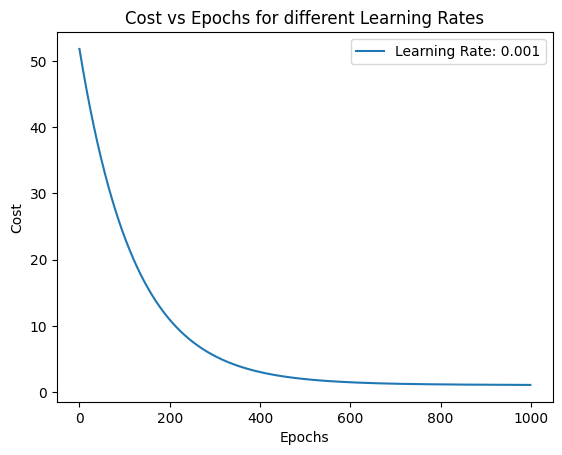

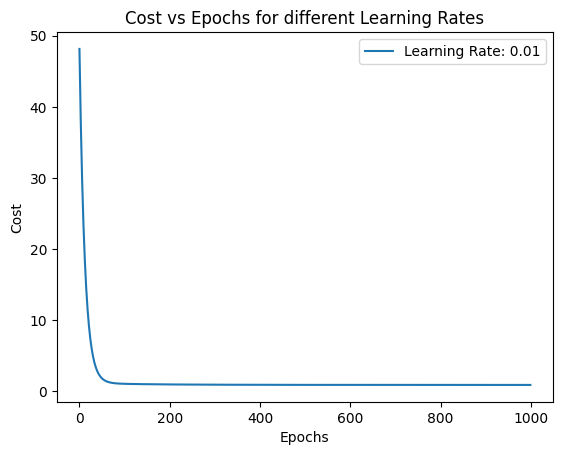

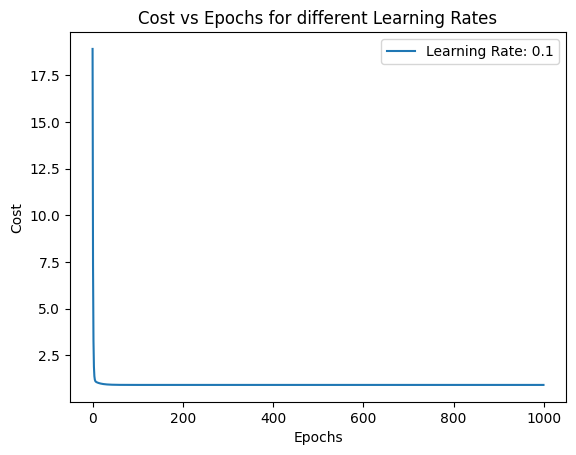

In [10]:
#plot the loss(cost) function vs epochs to visualize the convergence of the gradient descent algorithm
def compute_cost(m, b, points):
    N = float(len(points))
    total_cost = 0
    for i in range(0, len(points)):
        x = points[i, 0]
        y = points[i, 1]
        total_cost += (y - (m * x + b)) ** 2
    return total_cost / N
for L in L_values:
    m = 0
    b = 0
    cost_history = []
    for i in range(epochs):
        m, b = gradient_descent(m, b, np.hstack((X_train, y_train)), L)
        cost = compute_cost(m, b, np.hstack((X_train, y_train)))
        cost_history.append(cost)
    plt.plot(range(epochs), cost_history, label=f'Learning Rate: {L}')
    plt.xlabel('Epochs')
    plt.ylabel('Cost')
    plt.title('Cost vs Epochs for different Learning Rates')
    plt.legend()
    plt.show()